In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("../data/processed/german_credit_clean.csv")

df.head()

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,target_binary
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,1


In [4]:
target = "target_binary"

numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "num_dependents"
]

categorical_features = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment_since",
    "personal_status_sex",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

X = df[numeric_features + categorical_features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (1000, 20)
y shape: (1000,)
target_binary
0    700
1    300
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 20)
Testing set: (200, 20)


In [6]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_onehot = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
numeric_transformer_hgb = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer_hgb = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor_ordinal = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_hgb, numeric_features),
        ("cat", categorical_transformer_hgb, categorical_features)
    ]
)

In [8]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_onehot),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_onehot),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_onehot),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor_ordinal),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            random_state=42
        ))
    ])
}

In [9]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training HistGradientBoosting...


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.750,0.558140,0.800000,0.657534,0.805833
1,Decision Tree,0.570,0.377358,0.666667,0.481928,0.598988
2,Random Forest,0.755,0.590164,0.600000,0.595041,0.803095
3,HistGradientBoosting,0.765,0.644444,0.483333,0.552381,0.797024


In [10]:
results_df_sorted = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df_sorted

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.750,0.558140,0.800000,0.657534,0.805833
2,Random Forest,0.755,0.590164,0.600000,0.595041,0.803095
3,HistGradientBoosting,0.765,0.644444,0.483333,0.552381,0.797024
1,Decision Tree,0.570,0.377358,0.666667,0.481928,0.598988


In [11]:
tables_path = Path("../outputs/tables")
tables_path.mkdir(parents=True, exist_ok=True)

results_df_sorted.to_csv(tables_path / "model_comparison_results.csv", index=False)

print("Saved model comparison results.")

Saved model comparison results.


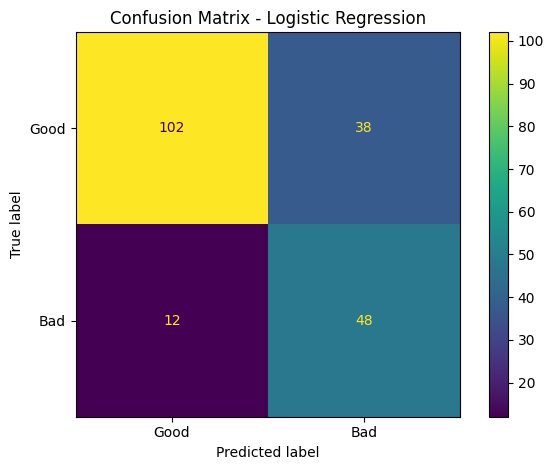

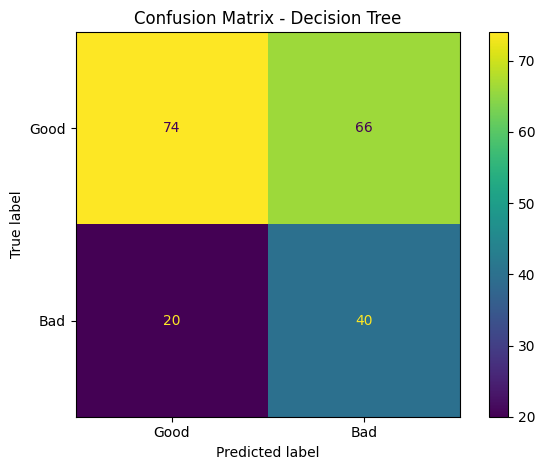

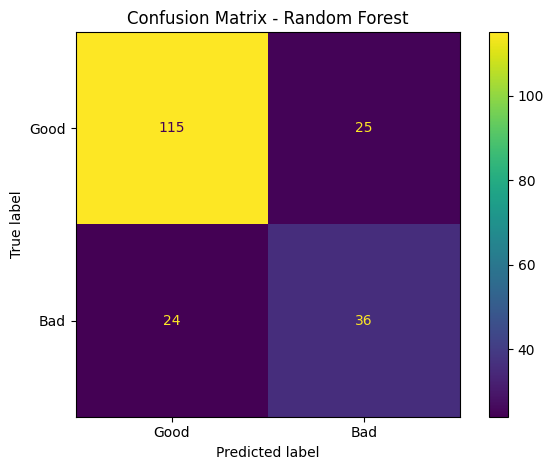

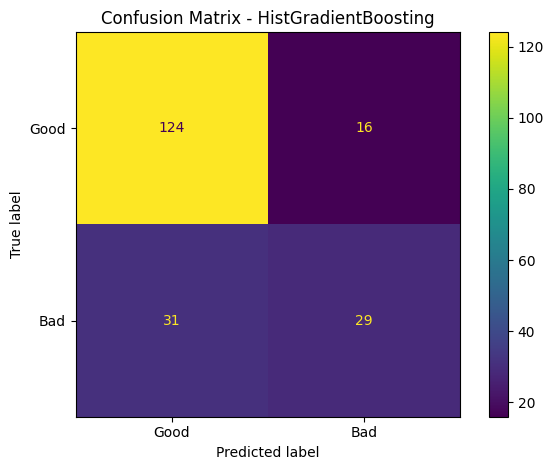

In [12]:
figures_path = Path("../outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Good", "Bad"]
    )
    
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    
    file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(figures_path / file_name, dpi=300, bbox_inches="tight")
    plt.show()

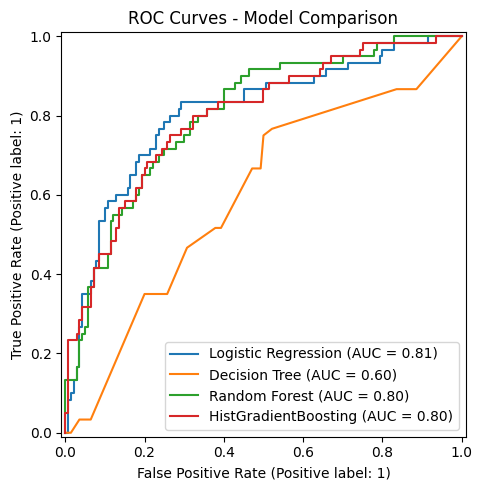

In [13]:
plt.figure(figsize=(7, 5))

for model_name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curves - Model Comparison")
plt.tight_layout()
plt.savefig(figures_path / "roc_curves_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
for model_name, model in models.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    y_pred = model.predict(X_test)
    
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Good Credit Risk", "Bad Credit Risk"]
    ))

Logistic Regression
                  precision    recall  f1-score   support

Good Credit Risk       0.89      0.73      0.80       140
 Bad Credit Risk       0.56      0.80      0.66        60

        accuracy                           0.75       200
       macro avg       0.73      0.76      0.73       200
    weighted avg       0.79      0.75      0.76       200

Decision Tree
                  precision    recall  f1-score   support

Good Credit Risk       0.79      0.53      0.63       140
 Bad Credit Risk       0.38      0.67      0.48        60

        accuracy                           0.57       200
       macro avg       0.58      0.60      0.56       200
    weighted avg       0.66      0.57      0.59       200

Random Forest
                  precision    recall  f1-score   support

Good Credit Risk       0.83      0.82      0.82       140
 Bad Credit Risk       0.59      0.60      0.60        60

        accuracy                           0.76       200
       macro avg

In [15]:
import joblib

models_path = Path("../outputs/models")
models_path.mkdir(parents=True, exist_ok=True)

for model_name, model in models.items():
    file_name = model_name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, models_path / file_name)

print("Saved trained models.")

Saved trained models.
